# ARMA Results Visualization (Validation vs Test)

This notebook generates report-ready ARMA summaries from:
- fixed-parameter runs (`arma_outputs`)
- tuning runs (`arma_tuning_outputs`)

It keeps validation and test views separate, ranks by RMSE, and displays plots inline.

In [5]:
%matplotlib inline

from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd

plt.style.use("seaborn-v0_8-whitegrid")


def find_project_root(start: Path | None = None) -> Path:
    current = (start or Path.cwd()).resolve()
    for candidate in [current, *current.parents]:
        if (candidate / "src" / "config.py").exists():
            return candidate
    raise FileNotFoundError("Could not locate project root containing src/config.py")


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import DEFAULT_CONFIG


def ensure_dir(path: str | Path) -> Path:
    path = Path(path)
    path.mkdir(parents=True, exist_ok=True)
    return path


def safe_read_csv(path: Path, required_cols: list[str] | None = None) -> pd.DataFrame | None:
    if not path.exists():
        return None
    df = pd.read_csv(path)
    if required_cols is not None:
        missing = set(required_cols) - set(df.columns)
        if missing:
            raise ValueError(f"File {path} missing required columns: {sorted(missing)}")
    return df


def make_model_label(df: pd.DataFrame) -> pd.Series:
    return (
        df["window_label"].astype(str)
        + " | "
        + df["pair"].astype(str)
        + " | "
        + df["eval_split"].astype(str)
    )


def add_rmse_rank(df: pd.DataFrame) -> pd.DataFrame:
    out = df.copy().sort_values(["rmse", "mae"]).reset_index(drop=True)
    out["rank_rmse"] = out.index + 1
    return out


def maybe_filter(df: pd.DataFrame, window: str | None, pair: str | None) -> pd.DataFrame:
    out = df.copy()
    if window is not None and "window_label" in out.columns:
        out = out[out["window_label"] == window]
    if pair is not None and "pair" in out.columns:
        out = out[out["pair"] == pair]
    return out.copy()


def plot_top_barh(df: pd.DataFrame, metric: str, title: str, top_n: int = 15) -> None:
    ranked = df.sort_values(metric, ascending=True).head(top_n).copy()
    if ranked.empty:
        print(f"No rows to plot for {title}")
        return

    ranked["label"] = make_model_label(ranked)
    plt.figure(figsize=(13, max(6, 0.45 * len(ranked))))
    plt.barh(ranked["label"], ranked[metric])
    plt.gca().invert_yaxis()
    plt.xlabel(metric.upper())
    plt.ylabel("Model (window | pair | split)")
    plt.title(title)
    plt.tight_layout()
    plt.show()


def plot_grouped_rmse_mae(df: pd.DataFrame, title: str, top_n: int = 10) -> None:
    ranked = df.sort_values("rmse", ascending=True).head(top_n).copy()
    if ranked.empty:
        print(f"No rows to plot for {title}")
        return

    ranked["label"] = make_model_label(ranked)
    x = range(len(ranked))
    width = 0.4

    plt.figure(figsize=(14, 6))
    plt.bar([i - width / 2 for i in x], ranked["rmse"], width=width, label="RMSE")
    plt.bar([i + width / 2 for i in x], ranked["mae"], width=width, label="MAE")
    plt.xticks(list(x), ranked["label"], rotation=35, ha="right")
    plt.ylabel("Metric Value")
    plt.title(title)
    plt.legend()
    plt.tight_layout()
    plt.show()


def find_best_row(df: pd.DataFrame) -> pd.Series | None:
    if df.empty:
        return None
    return df.sort_values(["rmse", "mae"]).iloc[0]


def load_forecasts_for_best(
    best_row: pd.Series,
    tuning_root: Path,
    fixed_root: Path,
    holdout_root: Path,
) -> pd.DataFrame | None:
    pair = str(best_row["pair"])
    window = str(best_row["window_label"])
    eval_split = str(best_row["eval_split"])

    safe_pair = pair.replace("/", "_")

    # 1) Preferred: holdout-eval per-pair forecasts
    holdout_candidates = [
        holdout_root / window / "pairs" / safe_pair / "arma_forecasts_holdout.csv",
        holdout_root / window / "pairs" / safe_pair / "arma_forecasts_test.csv",
    ]
    for path in holdout_candidates:
        df = safe_read_csv(path, required_cols=["Date", "actual", "predicted"])
        if df is not None:
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            return df.dropna(subset=["Date"]).sort_values("Date")

    # 2) Tuning best forecasts
    tuning_candidates = [
        tuning_root / window / "pairs" / safe_pair / "arma_forecasts_test_best.csv",
        tuning_root / window / "pairs" / safe_pair / "arma_forecasts_val_best.csv",
    ]
    for path in tuning_candidates:
        df = safe_read_csv(path, required_cols=["Date", "actual", "predicted"])
        if df is not None:
            df["Date"] = pd.to_datetime(df["Date"], errors="coerce")
            return df.dropna(subset=["Date"]).sort_values("Date")

    # 3) Fixed-output aggregate forecasts
    fixed_path = fixed_root / window / "all_forecasts.csv"
    fixed_df = safe_read_csv(fixed_path, required_cols=["Date", "pair", "actual", "predicted"])
    if fixed_df is None:
        return None
    fixed_df["Date"] = pd.to_datetime(fixed_df["Date"], errors="coerce")
    fixed_df = fixed_df.dropna(subset=["Date"]).copy()
    mask = fixed_df["pair"].astype(str) == pair
    if "eval_split" in fixed_df.columns:
        mask = mask & (fixed_df["eval_split"].astype(str) == eval_split)
    out = fixed_df.loc[mask].sort_values("Date")
    return out if not out.empty else None


def plot_best_diagnostics(best_row: pd.Series, forecast_df: pd.DataFrame | None) -> None:
    if best_row is None:
        print("No best model available.")
        return
    if forecast_df is None or forecast_df.empty:
        print("Best model forecasts not found for diagnostics.")
        return

    suffix = f"{best_row['window_label']} | {best_row['pair']} | {best_row['eval_split']}"
    df = forecast_df.copy()
    if "forecast_error" not in df.columns:
        df["forecast_error"] = df["actual"] - df["predicted"]

    plt.figure(figsize=(13, 5))
    plt.plot(df["Date"], df["actual"], label="Actual")
    plt.plot(df["Date"], df["predicted"], label="Predicted")
    plt.xlabel("Date")
    plt.ylabel("Spread")
    plt.title(f"Best Model Actual vs Predicted ({suffix})")
    plt.legend()
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(13, 5))
    plt.plot(df["Date"], df["forecast_error"])
    plt.axhline(0)
    plt.xlabel("Date")
    plt.ylabel("Residual")
    plt.title(f"Best Model Residuals Over Time ({suffix})")
    plt.tight_layout()
    plt.show()

    plt.figure(figsize=(9, 5))
    plt.hist(df["forecast_error"].dropna(), bins=30, edgecolor="white")
    plt.xlabel("Residual")
    plt.ylabel("Frequency")
    plt.title(f"Best Model Residual Distribution ({suffix})")
    plt.tight_layout()
    plt.show()


In [6]:
# Config
tuning_root = DEFAULT_CONFIG.processed_dir / "arma_tuning_outputs"
fixed_root = DEFAULT_CONFIG.processed_dir / "arma_outputs"
holdout_root = DEFAULT_CONFIG.processed_dir / "arma_holdout_outputs"
final_holdout_path = holdout_root / "final_holdout_results.csv"
selected_params_path = holdout_root / "selected_holdout_params.csv"
top_n = 15

# Optional filters
window_filter = None  # e.g. "2010_2016"
pair_filter = None    # e.g. "aapl-msft"

print(f"Tuning root: {tuning_root}")
print(f"Fixed root: {fixed_root}")
print(f"Holdout root: {holdout_root}")
print(f"Final holdout file: {final_holdout_path}")
print(f"Selected params file: {selected_params_path}")


Tuning root: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/arma_tuning_outputs
Fixed root: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/arma_outputs
Holdout root: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/arma_holdout_outputs
Final holdout file: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/arma_holdout_outputs/final_holdout_results.csv
Selected params file: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/arma_holdout_outputs/selected_holdout_params.csv


## Load Validation and Test Summaries

In [7]:
all_val_path = tuning_root / "all_validation_results.csv"
best_val_path = tuning_root / "best_validation_results.csv"
test_path = tuning_root / "test_results.csv"

all_validation_df = safe_read_csv(all_val_path)
best_validation_df = safe_read_csv(best_val_path)
test_results_df = safe_read_csv(test_path)
holdout_results_df = safe_read_csv(final_holdout_path)
holdout_params_df = safe_read_csv(selected_params_path)

if all_validation_df is None:
    print(f"Missing: {all_val_path}")
else:
    print(f"Loaded all_validation_results: {len(all_validation_df)} rows")

if best_validation_df is None:
    print(f"Missing: {best_val_path}")
else:
    print(f"Loaded best_validation_results: {len(best_validation_df)} rows")

if test_results_df is None:
    print(f"Optional legacy file missing: {test_path}")
else:
    print(f"Loaded legacy test_results: {len(test_results_df)} rows")

if holdout_results_df is None:
    print(f"Holdout results file not found: {final_holdout_path}")
else:
    print(f"Loaded final_holdout_results: {len(holdout_results_df)} rows")

if holdout_params_df is None:
    print(f"Optional params file not found: {selected_params_path}")
else:
    print(f"Loaded selected_holdout_params: {len(holdout_params_df)} rows")


Loaded all_validation_results: 2000 rows
Loaded best_validation_results: 80 rows
Optional legacy file missing: /Users/priscillaashleywijaya/Desktop/Y2S2/CS3244/project/Pairs-Trading/data/processed/arma_tuning_outputs/test_results.csv
Loaded final_holdout_results: 8 rows
Loaded selected_holdout_params: 70 rows


## Validation Tuning Summary (for Model Selection)

In [8]:
if best_validation_df is None or best_validation_df.empty:
    print("No best validation data available.")
else:
    val_summary = best_validation_df.rename(columns={"best_p": "p", "best_q": "q"}).copy()
    if "eval_split" not in val_summary.columns:
        val_summary["eval_split"] = "val"

    required_cols = {"pair", "window_label", "rmse", "mae", "p", "q"}
    missing_cols = required_cols - set(val_summary.columns)
    if missing_cols:
        print(f"Validation summary missing required columns: {sorted(missing_cols)}")
        display(val_summary.head())
    else:
        val_summary = maybe_filter(val_summary, window_filter, pair_filter)
        val_summary = add_rmse_rank(val_summary)
        display(val_summary.head(20))

        plot_top_barh(
            val_summary,
            metric="rmse",
            title=f"Validation: Top {min(top_n, len(val_summary))} by RMSE",
            top_n=top_n,
        )
        plot_top_barh(
            val_summary,
            metric="mae",
            title=f"Validation: Top {min(top_n, len(val_summary))} by MAE",
            top_n=top_n,
        )
        plot_grouped_rmse_mae(
            val_summary,
            title=f"Validation: RMSE vs MAE (Top {min(10, len(val_summary))})",
            top_n=min(10, top_n),
        )

Validation summary missing required columns: ['pair']


,arpair,window_label,p,q,rmse,mae,n_train,n_eval,spread_col,eval_split
0,aeo-gps,2010_2012,3,1,0.328403,0.279085,753,252,spread_ols,val
1,agco-etn,2010_2012,2,3,0.201630,0.186952,753,252,spread_ols,val
2,alks-cpa,2010_2012,2,5,0.186406,0.159634,753,252,spread_ols,val
3,alks-prgo,2010_2012,1,2,0.447664,0.415918,753,252,spread_ols,val
4,alks-spgi,2010_2012,5,5,0.376383,0.360635,753,252,spread_ols,val


## Final Test Summary (for Reporting)

Using source: final_holdout_results.csv (preferred final unseen holdout)

Selected holdout parameters preview:


,pair,selected_p,selected_q,mean_val_rmse,mean_val_mae,n_tuning_windows
0,adbe-noc,3,2,0.068355,0.056005,1
1,aee-d,5,4,0.048835,0.043166,1
2,aeo-gps,3,1,0.328403,0.279085,1
3,aep-gxp,2,4,0.060415,0.052602,1
4,aes-msci,2,4,0.226784,0.205796,2
5,agco-etn,2,3,0.201630,0.186952,1
6,alks-cpa,2,5,0.186406,0.159634,1
7,alks-prgo,1,2,0.447664,0.415918,1
8,alks-spgi,5,5,0.376383,0.360635,1
9,amp-ivz,3,2,0.033687,0.027510,1



Final report summary preview:


,pair,window_label,eval_split,selected_p,selected_q,rmse,mae,n_train,n_eval,spread_col,mean_val_rmse,mean_val_mae,n_tuning_windows,rank_rmse
0,cme-syk,2010_2016,test,5,5,0.044146,0.036624,1761,218,spread_ols,0.070880,0.054740,1,1
1,aep-gxp,2010_2016,test,2,4,0.046260,0.035883,1761,218,spread_ols,0.060415,0.052602,1,2
2,cce-ice,2010_2016,test,4,3,0.058624,0.046596,1760,218,spread_ols,0.112369,0.086604,2,3
3,gxp-kmb,2010_2016,test,4,2,0.114175,0.081863,1761,218,spread_ols,0.072808,0.061578,1,4
4,rnr-un,2010_2016,test,1,2,0.146701,0.126368,1761,218,spread_ols,0.049411,0.040960,1,5
5,hsic-ice,2010_2016,test,3,5,0.165433,0.125731,1761,218,spread_ols,0.075724,0.064828,2,6
6,mdlz-nee,2010_2016,test,1,2,0.168014,0.141859,1761,218,spread_ols,0.039262,0.032111,1,7
7,dish-eat,2010_2016,test,3,3,0.279982,0.262468,1761,218,spread_ols,0.166728,0.148326,1,8


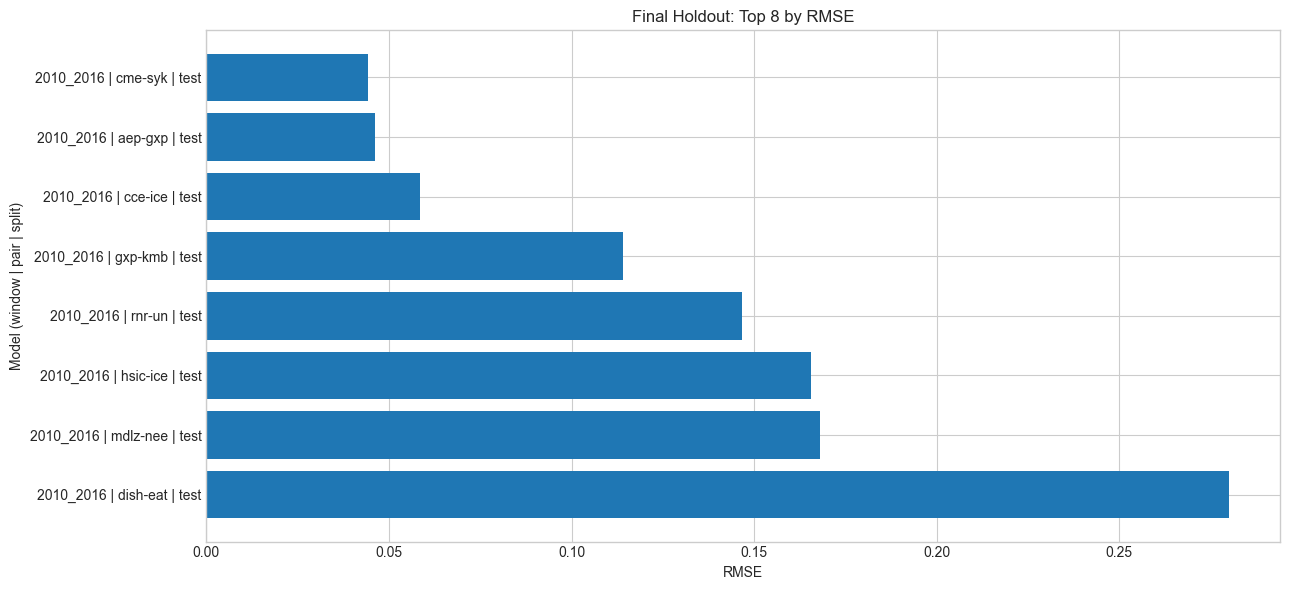

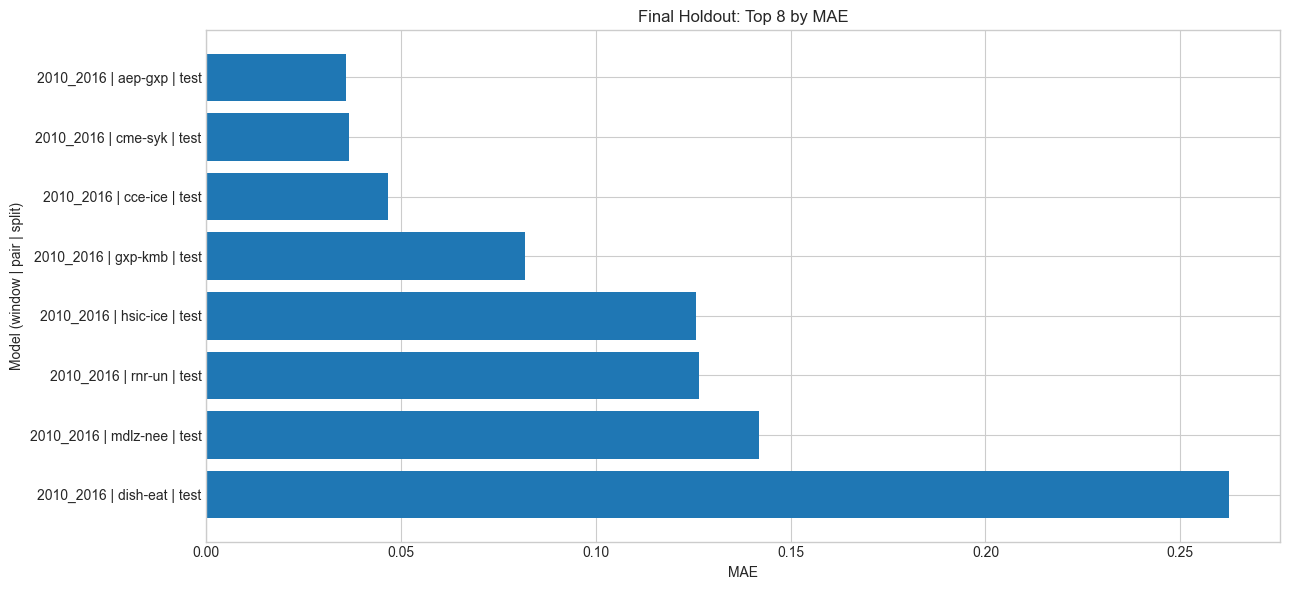

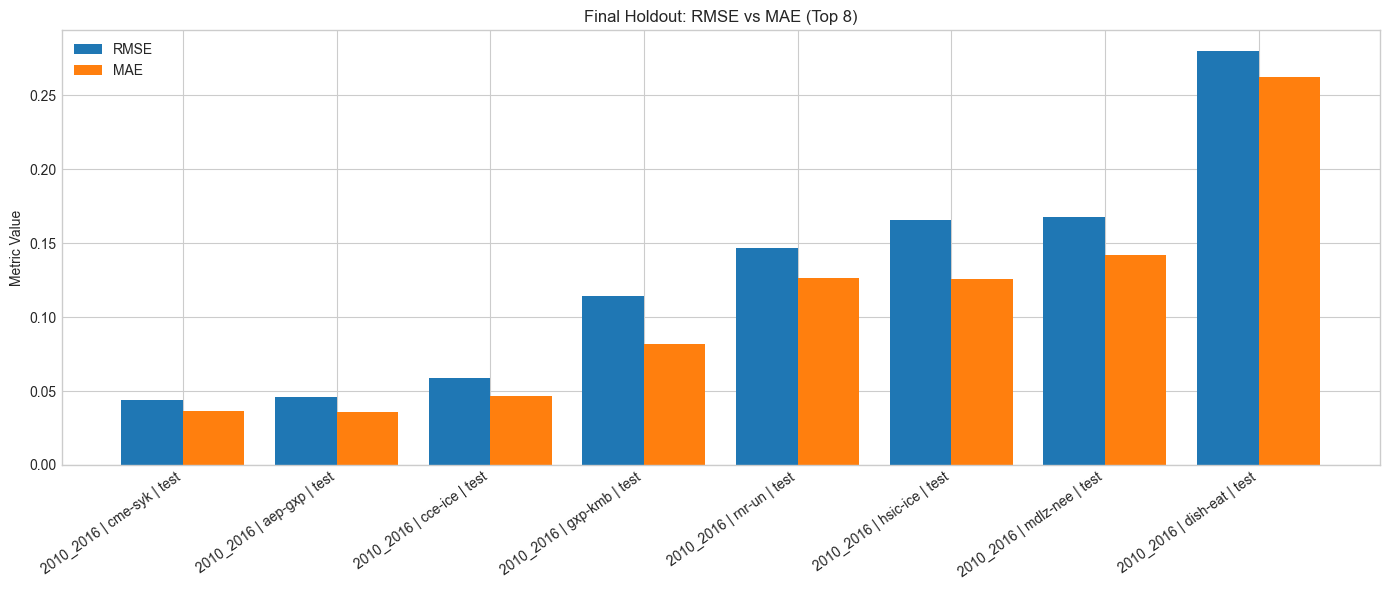

In [9]:
# Prefer holdout-eval output from arma_holdout_eval.py
if holdout_results_df is not None and not holdout_results_df.empty:
    print("Using source: final_holdout_results.csv (preferred final unseen holdout)")
    report_df = holdout_results_df.copy()
elif test_results_df is not None and not test_results_df.empty:
    print("Using source: tuning test_results.csv (fallback)")
    report_df = test_results_df.copy()
else:
    print("Using source: validation summary (last resort fallback)")
    report_df = val_summary.copy() if "val_summary" in globals() else pd.DataFrame()

if report_df is None or report_df.empty:
    print("No final report dataframe available.")
else:
    report_df = maybe_filter(report_df, window_filter, pair_filter)
    if "eval_split" not in report_df.columns:
        report_df["eval_split"] = "test"
    report_df = add_rmse_rank(report_df)

    if holdout_params_df is not None and not holdout_params_df.empty:
        params_view = maybe_filter(holdout_params_df, window=None, pair=pair_filter)
        print("\nSelected holdout parameters preview:")
        display(params_view[["pair", "selected_p", "selected_q", "mean_val_rmse", "mean_val_mae", "n_tuning_windows"]].head(20))

    print("\nFinal report summary preview:")
    display(report_df.head(20))

    plot_top_barh(
        report_df,
        metric="rmse",
        title=f"Final Holdout: Top {min(top_n, len(report_df))} by RMSE",
        top_n=top_n,
    )
    plot_top_barh(
        report_df,
        metric="mae",
        title=f"Final Holdout: Top {min(top_n, len(report_df))} by MAE",
        top_n=top_n,
    )
    plot_grouped_rmse_mae(
        report_df,
        title=f"Final Holdout: RMSE vs MAE (Top {min(10, len(report_df))})",
        top_n=min(10, top_n),
    )


## Best Model Diagnostics

,pair,window_label,eval_split,selected_p,selected_q,rmse,mae,n_train,n_eval,spread_col,mean_val_rmse,mean_val_mae,n_tuning_windows,rank_rmse
0,cme-syk,2010_2016,test,5,5,0.044146,0.036624,1761,218,spread_ols,0.07088,0.05474,1,1


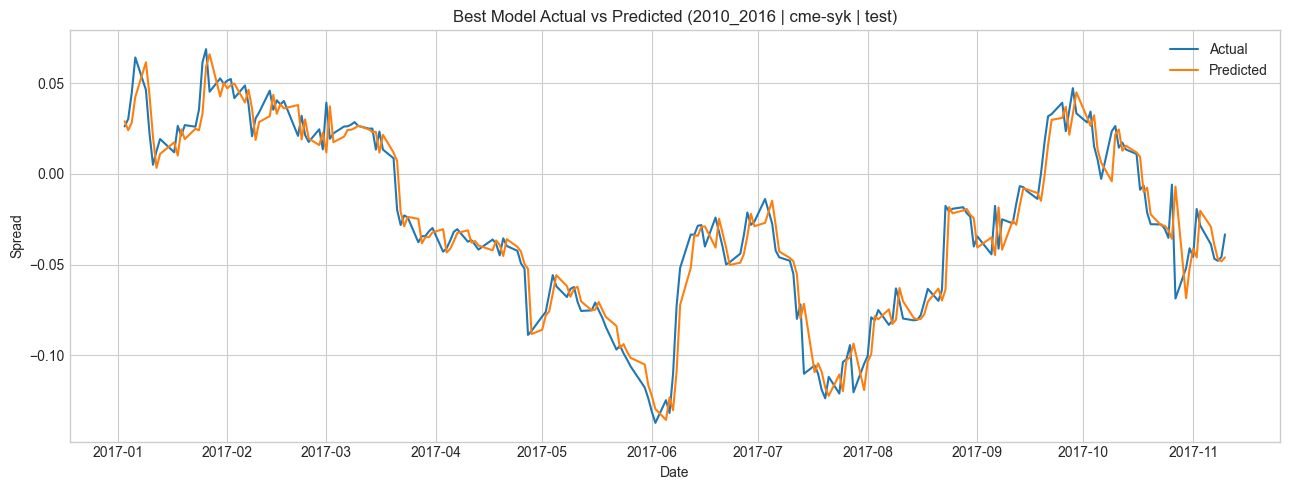

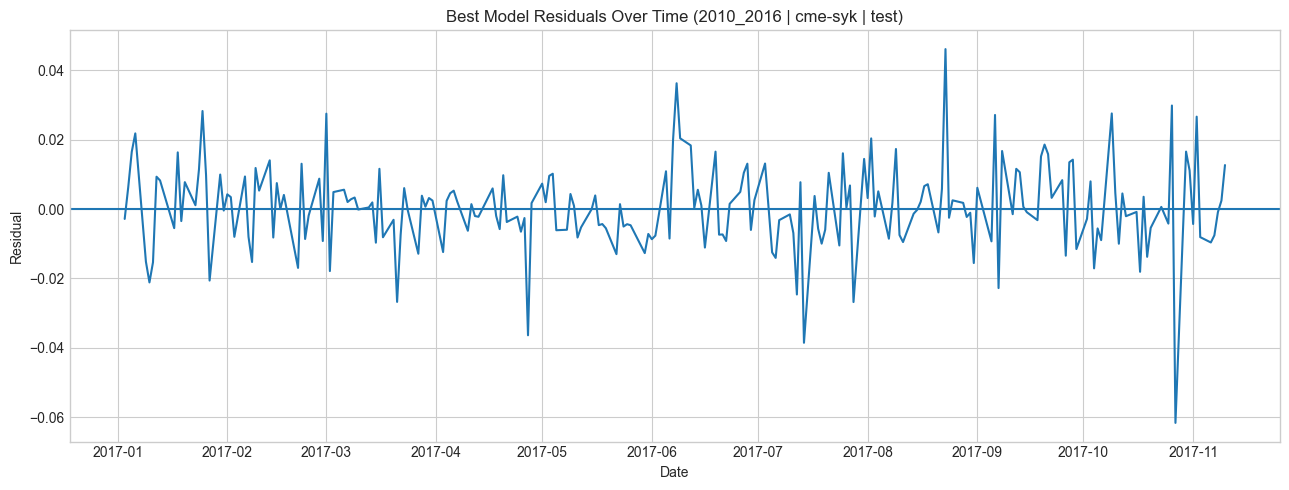

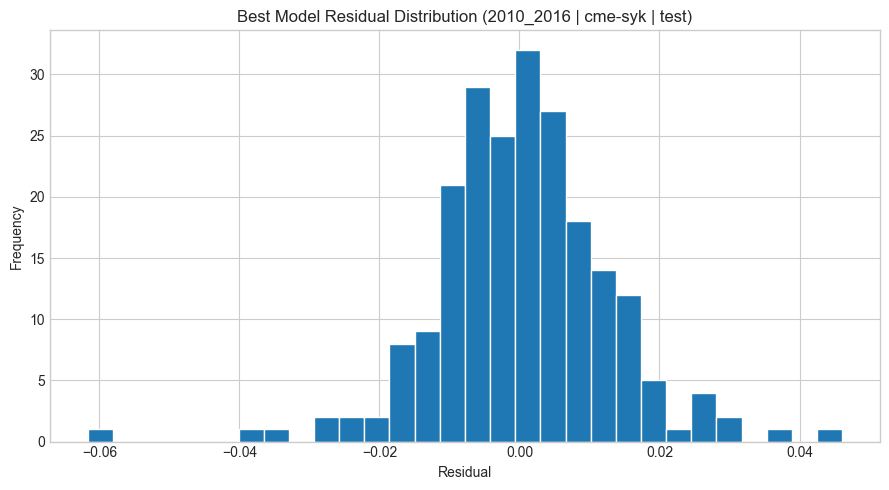

In [10]:
if report_df is None or report_df.empty:
    print("No report dataframe available for best-model diagnostics.")
else:
    best_row = find_best_row(report_df)
    display(pd.DataFrame([best_row]))
    best_forecasts = load_forecasts_for_best(
        best_row,
        tuning_root=tuning_root,
        fixed_root=fixed_root,
        holdout_root=holdout_root,
    )
    plot_best_diagnostics(best_row, best_forecasts)
